# Import Variables and Load Packages

In [3]:
import uproot
#print("uproot version: ", uproot.__version__)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import pickle
from collections import Counter
from particle import Particle
import matplotlib as mpl

import awkward as ak

f = uproot.open('/Users/katherinepulido/Desktop/H-KPMTcalibration/HKPMTcalibration/LIGen395_Pos0_hits_flat.root')
print(f.keys())

print(f['photonTree'].keys())
f['hitsTree'].keys()


['photonTree;2', 'photonTree;1', 'hitsTree;2', 'hitsTree;1']
['event', 'startX', 'startY', 'startZ', 'endX', 'endY', 'endZ']


['event', 'subevent', 'pmt_id', 'charge', 'time', 'posX', 'posY', 'posZ']

## Load Variables

In [4]:
photon = ['event', 
          'startX', 
          'startY', 
          'startZ', 
          'endX', 
          'endY', 
          'endZ'
        ]

hits = ['event', 'subevent', 'pmt_id', 'charge', 'time', 'posX', 'posY', 'posZ']

vars = {}
vars2 = {}
vars.update(f["photonTree"].arrays(photon, library="np"))
vars2.update(f["hitsTree"].arrays(hits, library="np"))

for key, value in vars.items():
    print(f"{key}: {len(value)}")

for key, value in vars2.items():
    print(f"{key}: {len(value)}")
    
for col in vars:
    vars[col] = vars[col].tolist()
    
for col in vars2:
    vars2[col] = vars2[col].tolist()

ph_df = pd.DataFrame(vars)
hit_df = pd.DataFrame(vars2)

event: 3404536
startX: 3404536
startY: 3404536
startZ: 3404536
endX: 3404536
endY: 3404536
endZ: 3404536
event: 3051901
subevent: 3051901
pmt_id: 3051901
charge: 3051901
time: 3051901
posX: 3051901
posY: 3051901
posZ: 3051901


In [5]:
#ph_df[ph_df["event"] == 9999]
#hit_df[hit_df["event"] == 9999]

#small_y_df = ph_df[abs(ph_df["startY"])<.0001]

moved_df = ph_df[
    (ph_df["startX"] != ph_df["endX"]) &
    (ph_df["startY"] != ph_df["endY"]) &
    (ph_df["startZ"] != ph_df["endZ"])
]

near_source_df = ph_df[ph_df["startX"]<40000]

moved_and_near_source_df = moved_df[abs(moved_df["startX"])<40000]

print(f'number of moved photons (start x,y,z != end x,y,z): {len(moved_df)}')
print(f'number of photons near source (startX<4000): {len(near_source_df)}')
print(f'number of photons that move and have startX<4000: {len(moved_and_near_source_df)}')

number of moved photons (start x,y,z != end x,y,z): 939103
number of photons near source (startX<4000): 3404536
number of photons that move and have startX<4000: 939103


# 3D Plotting

x: (-3242.76611328125, 3242.76611328125), y: (-3242.76611328125, 3242.76611328125), z: (-3296.47119140625, 3296.47119140625)


/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_34771/2272883570.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


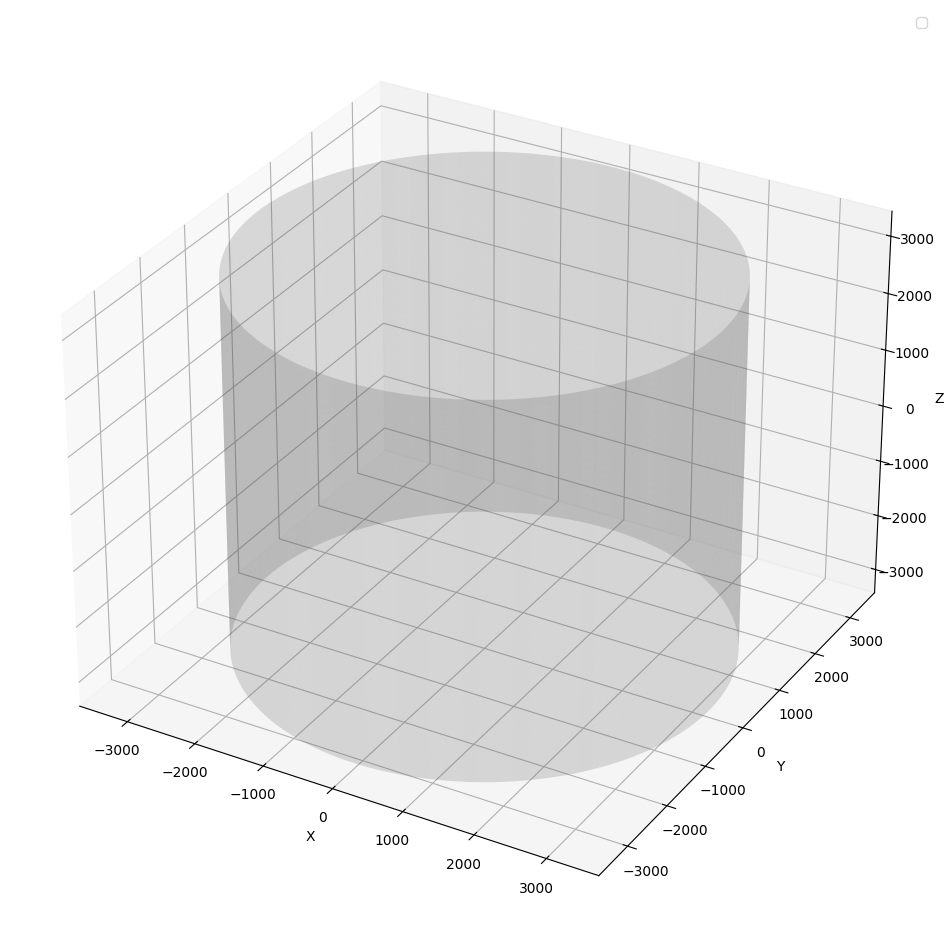

In [6]:
# standard cylinder

ax = plt.figure(figsize=(12,12)).add_subplot(projection='3d')

mpl.rcParams['agg.path.chunksize'] =  4051901

# Prepare arrays x, y, z
zs = hit_df["posZ"][:20000]
xs = hit_df["posX"][:20000]
ys = hit_df["posY"][:20000]

xmin = -3242.76611328125
xmax = 3242.76611328125
ymin = -3242.76611328125
ymax = 3242.76611328125
zmin = -3296.47119140625
zmax = 3296.47119140625

print(f'x: {xmin, xmax}, y: {ymin, ymax}, z: {zmin, zmax}')

radius = 3242.76611328125
z = np.linspace(-3296.47119140625, 3296.47119140625, 1000)
theta = np.linspace(0, 2*np.pi, 1000)
Theta, Zc = np.meshgrid(theta, z)
Xc = radius * np.cos(Theta)
Yc = radius * np.sin(Theta)

# Draw parameters
rstride = 20
cstride = 10
ax.plot_surface(Xc, Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')
ax.plot_surface(Xc, -Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend()

plt.show()

In [7]:
ax = plt.figure(figsize=(12,12)).add_subplot(projection='3d')

#cylinder
radius = 3242.76611328125
z = np.linspace(-3296.47119140625, 3296.47119140625, 1000)
theta = np.linspace(0, 2*np.pi, 1000)
Theta, Zc = np.meshgrid(theta, z)
Xc = radius * np.cos(Theta)
Yc = radius * np.sin(Theta)
# cyl parameters
rstride = 20
cstride = 10
ax.plot_surface(Xc, Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')
ax.plot_surface(Xc, -Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')

# photon trajectories

event_ph_df = ph_df[ph_df["event"] == 9999]
event_hit_df = hit_df[hit_df["event"] == 9999]

y_df = ph_df[abs(ph_df["endX"00]

#x_starts = y_df["startX"]
#y_starts = y_df["startY"]
#z_starts = y_df["startZ"]

x_starts = np.full(3220, y_df.shape[0])
y_starts = np.zeros(y_df.shape[0])
z_starts = np.full(-2465.66, y_df.shape[0])

x_ends = y_df["endX"]
y_ends = y_df["endY"]
z_ends = y_df["endZ"]

for xs, ys, zs, xe, ye, ze in zip(x_starts, y_starts, z_starts, x_ends, y_ends, z_ends):
    ax.plot([xs, xe], [ys, ye], [zs, ze], color='blue', alpha=0.5)
    print(xs, xe)

ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_zlabel("Z (cm)")
ax.legend()
plt.show()

SyntaxError: invalid syntax (4117566366.py, line 21)

In [ ]:
#hit_df["pmt_id"].value_counts().head(5)

hit_df["posZ"].value_counts().head(5)


posZ
-3296.471191    747496
 3296.471191    385513
-2472.511963     26591
-2401.827881     26270
-2543.196045     26131
Name: count, dtype: int64

/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


345


/Users/katherinepulido/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


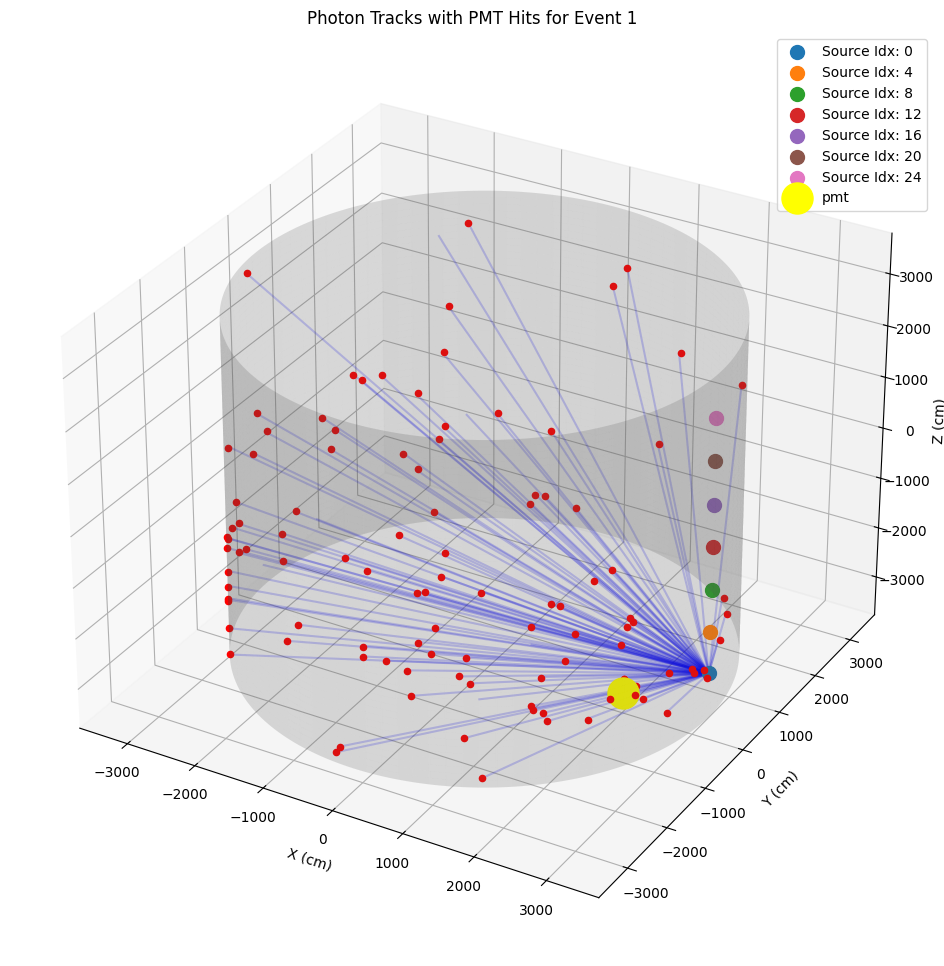

In [ ]:

def make_display(event_idx):    
    ax = plt.figure(figsize=(12,12)).add_subplot(projection='3d')

    #cylinder
    radius = 3242.76611328125
    z = np.linspace(-3296.47119140625, 3296.47119140625, 1000)
    theta = np.linspace(0, 2*np.pi, 1000)
    Theta, Zc = np.meshgrid(theta, z)
    Xc = radius * np.cos(Theta)
    Yc = radius * np.sin(Theta)
    # cyl parameters
    rstride = 20
    cstride = 10
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')
    ax.plot_surface(Xc, -Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')

    # add source positions
    source_positions = {
        0: (3220, 0, -2465.66),
        4: (3220, 0, -1643.78),
        8: (3220, 0, -821.88),
        12: (3220, 0, 0),
        16: (3220, 0, 821.888),
        20: (3220, 0, 1643.78),
        24: (3220, 0, 2465.66),
    }

    for key, (x, y, z) in source_positions.items():
        ax.scatter(x, y, z, label=f"Source Idx: {key}", s=100)

    event_ph_df = ph_df[ph_df["event"] == event_idx]
    event_hit_df = hit_df[hit_df["event"] == event_idx]

    # Apply filter
    y_df = event_ph_df
    #y_df = ph_df.sample(n=10000)

    # Only take 2000 rows
    #y_df = y_df.iloc[:50000]

    print(y_df.shape[0])


    # Start points
    #x_starts = np.full(y_df.shape[0], 3220)
    #y_starts = np.zeros(y_df.shape[0])
    #z_starts = np.full(y_df.shape[0], -2465.66)

    x_starts = y_df["startX"].values * 0.1
    y_starts = y_df["startY"].values * 0.1
    z_starts = y_df["startZ"].values * 0.1

    # End points
    x_ends = y_df["endX"].values * 0.1
    y_ends = y_df["endY"].values * 0.1
    z_ends = y_df["endZ"].values * 0.1
        
    pmt_xs = event_hit_df['posX']
    pmt_ys = event_hit_df['posY']
    pmt_zs = event_hit_df['posZ']
    pmt_charges = event_hit_df['charge']
    #event_hit_df['posX']

    # Plot line segments
    for xs, ys, zs, xe, ye, ze in zip(x_starts, y_starts, z_starts, x_ends, y_ends, z_ends):
        ax.plot([xs, xe], [ys, ye], [zs, ze], color='blue', alpha=0.2)
        for pmtx, pmty, pmtz, pmte, in zip(pmt_xs, pmt_ys, pmt_zs, pmt_charges):
            if np.linalg.norm(np.array([xe, ye, ze]) - np.array([pmtx, pmty, pmtz])) < 26.95:
                ax.scatter(pmtx, pmty, pmtz, color='red')
                
    pmt_hit_df = hit_df[hit_df["pmt_id"]==19343]

    x1 = pmt_hit_df["posX"].iloc[0] 
    y1 = pmt_hit_df["posY"].iloc[0] 
    z1 = pmt_hit_df["posZ"].iloc[0] 
    
    ax.scatter(x1, y1, z1, color='yellow', label='pmt', s=500)

    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.set_zlabel("Z (cm)")

    ax.legend()
    plt.title(f'Photon Tracks with PMT Hits for Event {event_idx}')

    plt.show()

make_display(1)

# make version for one PMT with angular dependence
# look for PMT with highest amt of hits
# hit count ratio as a function of incident angle



In [ ]:
pmt_hit_df = hit_df[hit_df["pmt_id"]==13007]

x1 = pmt_hit_df["posX"].iloc[0]
y1 = pmt_hit_df["posY"].iloc[0]
z1 = pmt_hit_df["posZ"].iloc[0]

print(x1, y1, z1)

3242.76611328125 35.37449645996094 -2472.511962890625


In [ ]:
import numpy as np
from scipy.spatial import cKDTree

def cartesian_to_cylindrical(x, y, z):
    """Convert Cartesian coordinates to cylindrical coordinates (r, phi, z)."""
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return r, phi, z

def get_cylinder_neighbours(target_pmt_id, pmt_positions_df, k=6, barrel_radius=3220):
    """
    Find nearest neighbours of a target PMT, accounting for cylinder geometry.
    
    Parameters
    ----------
    target_pmt_id : int
        PMT ID to find neighbours for.
    pmt_positions_df : pd.DataFrame
        Must contain columns: 'posX','posY','posZ','pmt_id'.
    k : int
        Number of PMTs to query (includes the target itself).
    barrel_radius : float
        Cylinder radius for barrel PMTs.
    
    Returns
    -------
    neighbour_ids : np.ndarray
        Array of PMT IDs of the nearest neighbours (excluding target).
    """
    
    # Find the target PMT
    target_row = pmt_positions_df[pmt_positions_df['pmt_id'] == target_pmt_id]
    if target_row.empty:
        raise ValueError(f"Target PMT {target_pmt_id} not found.")
    target_idx = target_row.index[0]

    # Determine if barrel or endcap
    x, y, z = target_row[['posX','posY','posZ']].values[0]
    r = np.sqrt(x**2 + y**2)
    if np.isclose(r, barrel_radius, atol=50):
        detector_type = 'barrel'
    else:
        detector_type = 'endcap'

    # Build surface-aware points
    if detector_type == 'barrel':
        _, phi, z_all = cartesian_to_cylindrical(
            pmt_positions_df['posX'].values,
            pmt_positions_df['posY'].values,
            pmt_positions_df['posZ'].values
        )
        points = np.column_stack([barrel_radius * phi, z_all])
    else:  # endcap
        points = pmt_positions_df[['posX','posY']].values

    # Build KDTree
    tree = cKDTree(points)

    # Query k nearest neighbours
    target_point = points[target_idx]
    distances, neighbour_indices = tree.query(target_point, k=k)
    neighbour_indices = neighbour_indices[1:]  # exclude target itself

    neighbour_ids = pmt_positions_df.iloc[neighbour_indices]['pmt_id'].values
    return neighbour_ids



target_pmt_id = 8003
neighbours = get_cylinder_neighbours(target_pmt_id, pmt_positions_df, k=6, barrel_radius=3220)

## Single PMT Analyses

  0%|          | 0/10000 [00:00<?, ?it/s]/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_34771/4232928285.py:53: RuntimeWarning: invalid value encountered in divide
  ph_vx /= ph_norm
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_34771/4232928285.py:54: RuntimeWarning: invalid value encountered in divide
  ph_vy /= ph_norm
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_34771/4232928285.py:55: RuntimeWarning: invalid value encountered in divide
  ph_vz /= ph_norm
100%|██████████| 10000/10000 [14:14<00:00, 11.70it/s]


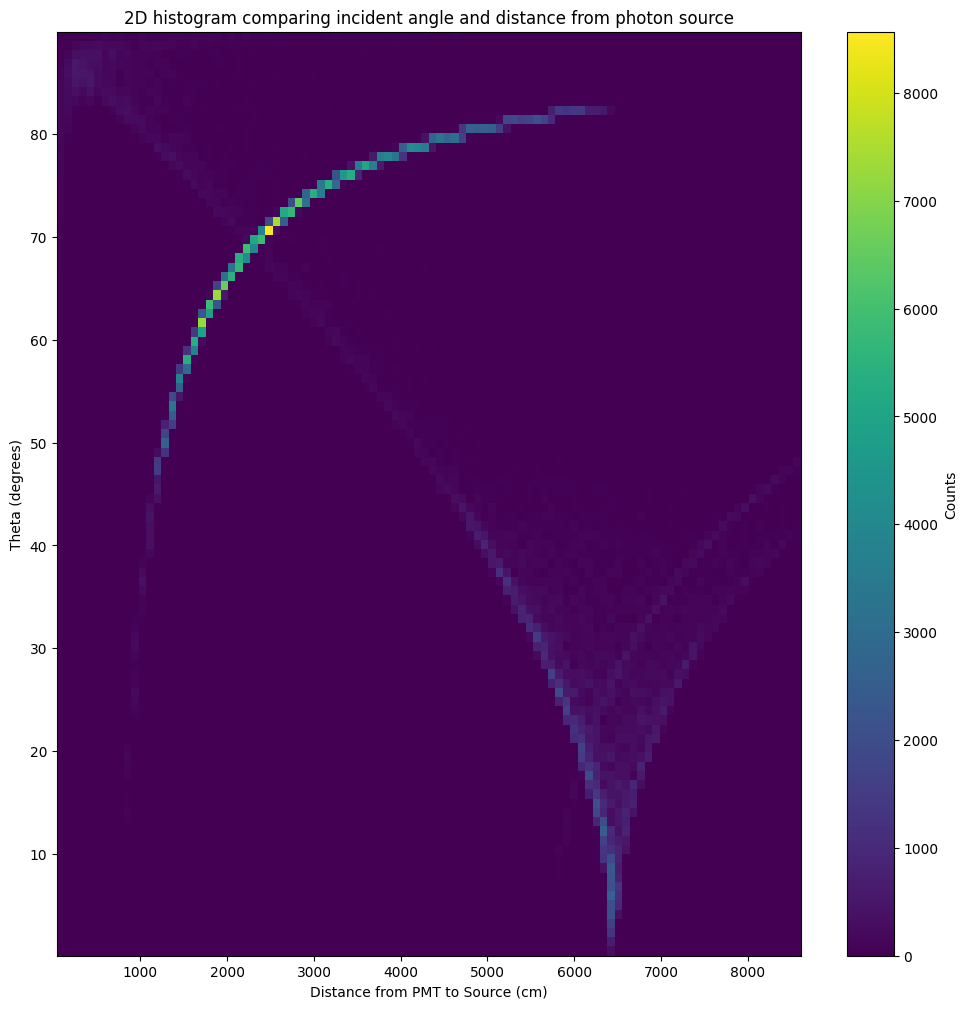

In [ ]:
#hit_df["posX"].mode()[0]
#x_common_df = hit_df[hit_df["posX"]==1341.4000244140625]
#y_common_df = x_common_df[x_common_df["posY"]==x_common_df["posY"].mode()[0]]
#z_common_df = y_common_df[y_common_df["posY"]==y_common_df["posY"].mode()[0]]

# ratio of hits based on azimuthal angle (x-axis) and distance from center of PMT

#common_df = hit_df[hit_df["pmt_id"]==hit_df["pmt_id"].mode()[0]]

x_ends = ph_df["endX"].values * 0.1
y_ends = ph_df["endY"].values * 0.1
z_ends = ph_df["endZ"].values * 0.1

x_starts = ph_df["startX"].values * 0.1
y_starts = ph_df["startY"].values * 0.1
z_starts = ph_df["startZ"].values * 0.1

def get_ang_pos(pmt_id):
    pmt_hit_df = hit_df[hit_df["pmt_id"] == pmt_id]
    pmt_x, pmt_y, pmt_z = pmt_hit_df["posX"].iloc[0], pmt_hit_df["posY"].iloc[0], pmt_hit_df["posZ"].iloc[0] 
    
    normal_vector = []

    # define normal vector of PMT
    if pmt_z == 3296.47119140625:
        normal_vector = np.array([0, 0,-1])
    elif pmt_z == -3296.47119140625:
        normal_vector = np.array([0, 0, 1])
    else:
        normal_vector = np.array([-pmt_x/radius, -pmt_y/radius, 0])

    # normalize normal vector
    normal_vector = normal_vector / np.linalg.norm(normal_vector)
    
    # vector from photon end to PMT center
    dx = x_ends - pmt_x
    dy = y_ends - pmt_y
    dz = z_ends - pmt_z

    center_dist = np.sqrt(dx**2 + dy**2 + dz**2)

    mask = center_dist < 50
    
    dist_to_source = np.sqrt((x_starts - pmt_x)**2 + (y_starts - pmt_y)**2 + (z_starts - pmt_z)**2)

    # photon direction
    ph_vx = x_starts - x_ends
    ph_vy = y_starts - y_ends
    ph_vz = z_starts - z_ends

    ph_norm = np.sqrt(ph_vx**2 + ph_vy**2 + ph_vz**2)

    ph_vx /= ph_norm
    ph_vy /= ph_norm
    ph_vz /= ph_norm

    cos_theta = (
        normal_vector[0]*ph_vx +
        normal_vector[1]*ph_vy +
        normal_vector[2]*ph_vz
    )

    theta = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
    
    weird_mask = mask & (theta>175)
    
    idx = np.where(weird_mask)[0]


    return theta[mask], dist_to_source[mask], idx

# find theta, distance for every pmt

from tqdm import tqdm

thetas = []
center_distances = []
all_idxs = []

unique_pmts = hit_df['pmt_id'].unique()

for id in tqdm(unique_pmts):
    theta, dist, idx = get_ang_pos(id)
    thetas.append(theta)
    center_distances.append(dist)
    all_idxs.append(idx)

all_idxs = np.concatenate(all_idxs)

selected_starts = np.stack([
    x_starts[all_idxs],
    y_starts[all_idxs],
    z_starts[all_idxs]
], axis=1)

selected_ends = np.stack([
    x_ends[all_idxs],
    y_ends[all_idxs],
    z_ends[all_idxs]
], axis=1)
    


# plot thetas vs center_distances on histogram

plt.figure(figsize=(12,12))

plt.hist2d(np.concatenate(center_distances), np.concatenate(thetas), bins=100)

plt.xlabel("Distance from PMT to Source (cm)")
plt.title("2D histogram comparing incident angle and distance from photon source")
plt.ylabel("Theta (degrees)")
plt.colorbar(label="Counts")




    
    
    
    # if close to PMT, calculate azimuthal angle and distance to center of PMT
    #for xs, ys, zs, xe, ye, ze in zip(x_starts, y_starts, z_starts, x_ends, y_ends, z_ends):
    #    if np.linalg.norm(np.array([xe, ye, ze]) - np.array([pmt_x, pmt_y, pmt_z])) < 30:
            
            
            
            
        
    #    ax.plot([xs, xe], [ys, ye], [zs, ze], color='blue', alpha=0.2)
    #    for pmtx, pmty, pmtz, pmte, in zip(pmt_xs, pmt_ys, pmt_zs, pmt_charges):
    #        if np.linalg.norm(np.array([xe, ye, ze]) - np.array([pmtx, pmty, pmtz])) < 26.9:
    #            ax.scatter(pmtx, pmty, pmtz, color='red')
            
            
            
            

#def get_azimuthal_angle









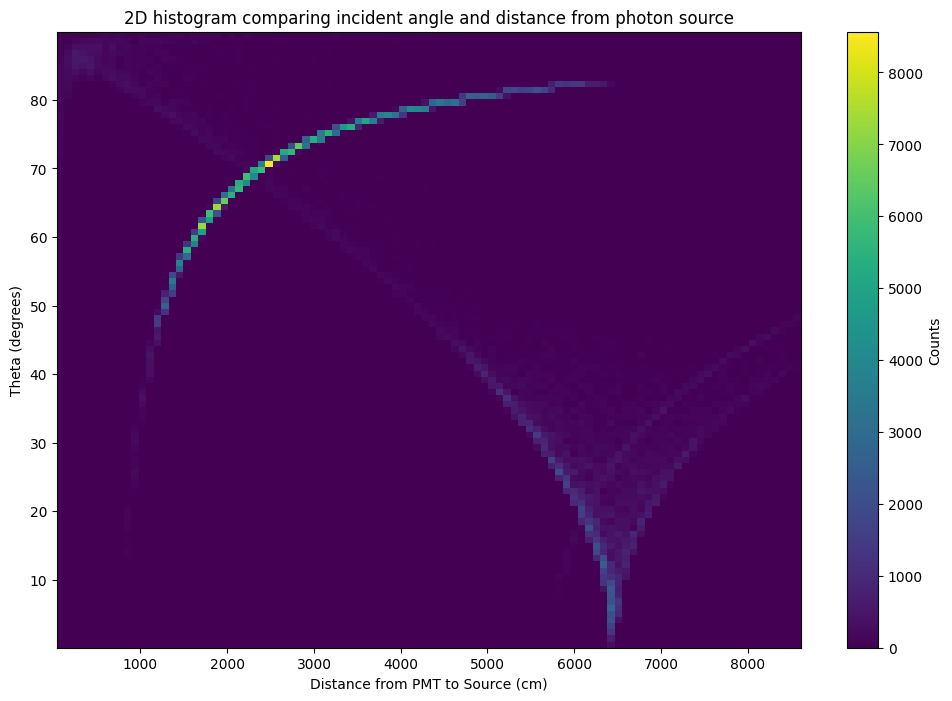

In [25]:
plt.figure(figsize=(12,8))

plt.hist2d(np.concatenate(center_distances), np.concatenate(thetas), bins=100)

plt.xlabel("Distance from PMT to Source (cm)")
plt.title("2D histogram comparing incident angle and distance from photon source")
plt.ylabel("Theta (degrees)")
plt.colorbar(label="Counts")

In [21]:


for xs, ys, zs, xe, ye, ze, theta in zip(
        x_starts[mask], y_starts[mask], z_starts[mask],
        x_ends[mask], y_ends[mask], z_ends[mask],
        thetas[mask]):

    print(f"start=({xs:.2f},{ys:.2f},{zs:.2f})  "
          f"end=({xe:.2f},{ye:.2f},{ze:.2f})  "
          f"theta={theta:.2f}")

NameError: name 'mask' is not defined

  0%|          | 0/19746 [00:00<?, ?it/s]/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_5986/3631428321.py:53: RuntimeWarning: invalid value encountered in divide
  ph_vx /= ph_norm
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_5986/3631428321.py:54: RuntimeWarning: invalid value encountered in divide
  ph_vy /= ph_norm
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_5986/3631428321.py:55: RuntimeWarning: invalid value encountered in divide
  ph_vz /= ph_norm
100%|██████████| 19746/19746 [30:11<00:00, 10.90it/s]


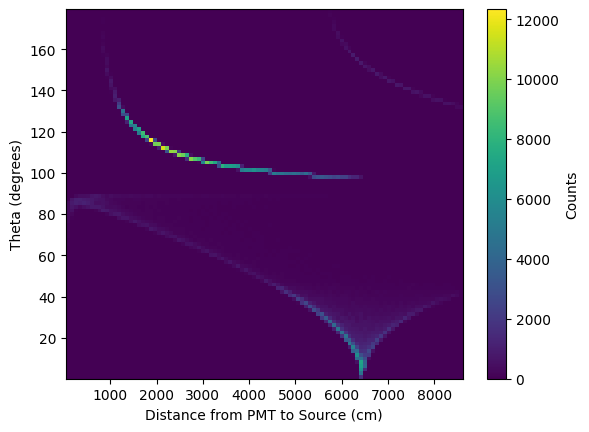

In [ ]:
thetas = []
center_distances = []

unique_pmts = hit_df['pmt_id'].unique()[:1000]

for id in tqdm(unique_pmts):
    theta, dist = get_ang_pos(id)
    thetas.append(theta)
    center_distances.append(dist)

# plot thetas vs center_distances on histogram

plt.figure()

plt.hist2d(np.concatenate(center_distances), np.concatenate(thetas), bins=100)

plt.xlabel("Distance from PMT to Source (cm)")
plt.ylabel("Theta (degrees)")
plt.colorbar(label="Counts")



In [15]:
# study large angle

unique_pmts = hit_df['pmt_id'].unique()[:1000]

for id in tqdm(unique_pmts):
    theta, dist, idx = get_ang_pos(id)
    thetas.append(theta)
    center_distances.append(dist)
    all_idxs.append(idx)

all_idxs = np.concatenate(all_idxs)

selected_starts = np.stack([
    x_starts[all_idxs],
    y_starts[all_idxs],
    z_starts[all_idxs]
], axis=1)

selected_ends = np.stack([
    x_ends[all_idxs],
    y_ends[all_idxs],
    z_ends[all_idxs]
], axis=1)


    

  0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_34771/1599682232.py:53: RuntimeWarning: invalid value encountered in divide
  ph_vx /= ph_norm
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_34771/1599682232.py:54: RuntimeWarning: invalid value encountered in divide
  ph_vy /= ph_norm
/var/folders/_s/7j_881g14zd1rn9kv4_hn7nw0000gn/T/ipykernel_34771/1599682232.py:55: RuntimeWarning: invalid value encountered in divide
  ph_vz /= ph_norm
100%|██████████| 1000/1000 [01:24<00:00, 11.82it/s]


3210.1771484375004 -1.8666498184204103 -2465.8296875 2897.0300781250003 -338.85307617187505 3273.6960937500003
3211.4619140625 -0.6620899200439454 -2460.4962890625 2883.105078125 -334.780419921875 3280.326171875
3211.7662109375 2.5627700805664064 -2470.7232421875 2896.3947265625 -353.447705078125 3269.6136718750004
3210.521484375 0.5234723567962647 -2462.5162109375 2889.5798828125003 -337.8877685546875 3274.76484375
3210.1890625 -1.8504253387451173 -2466.2271484375 2884.7740234375 -367.66672363281253 3276.1466796875
3210.8681640625 -3.050537490844727 -2462.9572265625 2916.4398437500004 -341.2173583984375 3286.0335937500004
3210.680859375 3.461984634399414 -2464.5791015625 2909.989453125 -370.72861328125003 3283.2953125000004
3210.247265625 2.1507055282592775 -2465.1529296875 2905.7279296875004 -366.22783203125005 3275.8328125000003
3211.9296875 5.897796249389649 -2465.9546875 2879.3228515625 -346.35712890625 3275.3232421875


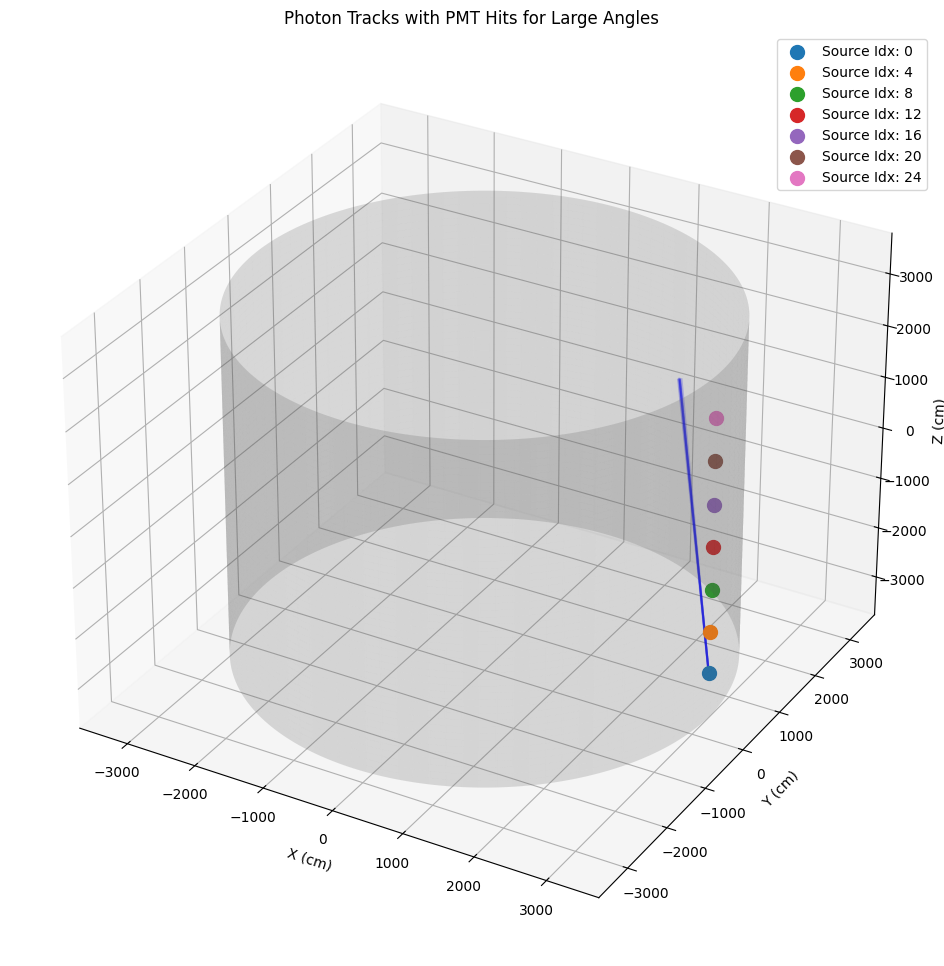

In [ ]:

    ax = plt.figure(figsize=(12,12)).add_subplot(projection='3d')

    #cylinder
    radius = 3242.76611328125
    z = np.linspace(-3296.47119140625, 3296.47119140625, 1000)
    theta = np.linspace(0, 2*np.pi, 1000)
    Theta, Zc = np.meshgrid(theta, z)
    Xc = radius * np.cos(Theta)
    Yc = radius * np.sin(Theta)
    # cyl parameters
    rstride = 20
    cstride = 10
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')
    ax.plot_surface(Xc, -Yc, Zc, alpha=0.1, rstride=rstride, cstride=cstride, color='grey')

    # add source positions
    source_positions = {
        0: (3220, 0, -2465.66),
        4: (3220, 0, -1643.78),
        8: (3220, 0, -821.88),
        12: (3220, 0, 0),
        16: (3220, 0, 821.888),
        20: (3220, 0, 1643.78),
        24: (3220, 0, 2465.66),
    }

    for key, (x, y, z) in source_positions.items():
        ax.scatter(x, y, z, label=f"Source Idx: {key}", s=100)

    #event_ph_df = ph_df[ph_df["event"] == event_idx]
    #vent_hit_df = hit_df[hit_df["event"] == event_idx]

    # Apply filter
    #y_df = event_ph_df
    #y_df = ph_df.sample(n=10000)

    # Only take 2000 rows
    #y_df = y_df.iloc[:50000]

    #print(y_df.shape[0])


    # Start points
    #x_starts = np.full(y_df.shape[0], 3220)
    #y_starts = np.zeros(y_df.shape[0])
    #z_starts = np.full(y_df.shape[0], -2465.66)
        
    pmt_xs = hit_df['posX']
    pmt_ys = hit_df['posY']
    pmt_zs = hit_df['posZ']
    pmt_charges = hit_df['charge']
    #event_hit_df['posX']

    # Plot line segments
    for start, end in zip(selected_starts, selected_ends):
        xs, ys, zs = start
        xe, ye, ze = end

        print(xs, ys, zs, xe, ye, ze)
        ax.plot([xs, xe], [ys, ye], [zs, ze], color='blue', alpha=0.2)
        #for pmtx, pmty, pmtz, pmte, in zip(pmt_xs, pmt_ys, pmt_zs, pmt_charges):
        #    if np.linalg.norm(np.array([xe, ye, ze]) - np.array([pmtx, pmty, pmtz])) < 26.95:
        #        ax.scatter(pmtx, pmty, pmtz, color='red')
                
    pmt_hit_df = hit_df[hit_df["pmt_id"]==19343]

    x1 = pmt_hit_df["posX"].iloc[0] 
    y1 = pmt_hit_df["posY"].iloc[0] 
    z1 = pmt_hit_df["posZ"].iloc[0] 
    
    #ax.scatter(x1, y1, z1, color='yellow', label='pmt', s=500)

    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    ax.set_zlabel("Z (cm)")

    ax.legend()
    plt.title(f'Photon Tracks with PMT Hits for Large Angles')

    plt.show()